In [81]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [37]:
# Je définis mes features
X = df.drop("species", axis=1)

In [38]:
# Je standardise mes données grace a minmaxscaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# J'instancie mon modèle avec le nombre de clusters choisi

model = KMeans(n_clusters=3)

In [41]:
# J'entraine mon modèle avec le .fit()
model = model.fit(X_scaled)

In [42]:
# J'ajoute ma colonne cluster à mon dataframe et je regarde si elle est bien ajoutée

df["cluster"] = model.labels_
display(df['cluster'].value_counts()) # J'ai bien mes 3 clusters 0, 1 et 2
df.sample(10)

cluster
1    52
2    50
0    48
Name: count, dtype: int64

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
35,5.0,3.2,1.2,0.2,setosa,2
86,6.7,3.1,4.7,1.5,versicolor,1
10,5.4,3.7,1.5,0.2,setosa,2
137,6.4,3.1,5.5,1.8,virginica,1
58,6.6,2.9,4.6,1.3,versicolor,0
44,5.1,3.8,1.9,0.4,setosa,2
91,6.1,3.0,4.6,1.4,versicolor,0
120,6.9,3.2,5.7,2.3,virginica,1
69,5.6,2.5,3.9,1.1,versicolor,0
139,6.9,3.1,5.4,2.1,virginica,1


In [70]:
# Je récupère les centres de mes clusters

model.cluster_centers_

array([[0.41203704, 0.27690972, 0.55896893, 0.52083333],
       [0.66773504, 0.44310897, 0.7571708 , 0.78205128],
       [0.19611111, 0.595     , 0.07830508, 0.06083333]])

In [71]:
# J'inverse la transformation pour avoir les centres de mes clusters dans les unités d'origine
croix = scaler.inverse_transform(model.cluster_centers_)

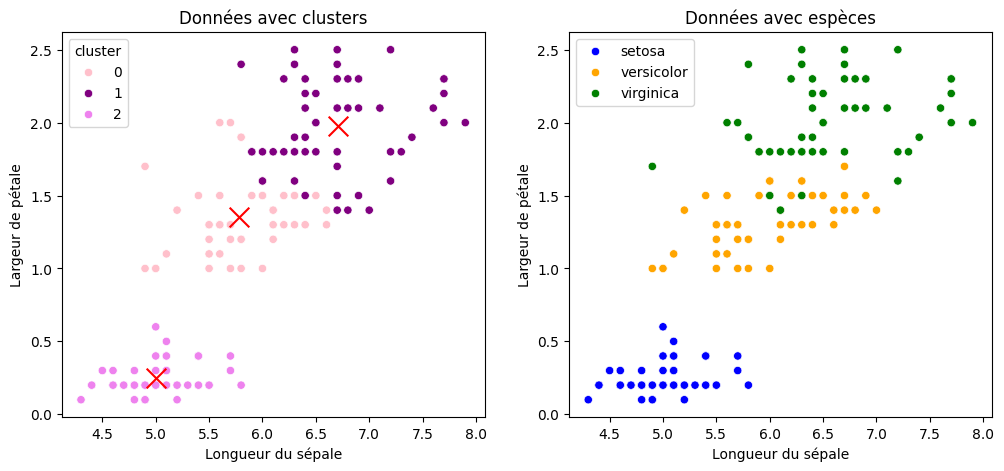

In [74]:
# Je fais un scatter plot pour visualiser mon dataset de base a gauche et mon dataset avec les clusters a droite
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='sepal_length', y='petal_width', ax=axes[0], hue='cluster', palette=['pink', 'purple', 'violet'])
axes[0].scatter(croix[:, 0], croix[:, 3], marker='x', c='red', s=200)
axes[0].set_title('Données avec clusters')
axes[0].set_xlabel('Longueur du sépale')
axes[0].set_ylabel('Largeur de pétale')
sns.scatterplot(data=df, x='sepal_length', y='petal_width', ax=axes[1], hue='species', palette=['blue', 'orange', 'green'])
axes[1].set_title('Données avec espèces')
axes[1].set_xlabel('Longueur du sépale')
axes[1].set_ylabel('Largeur de pétale')
plt.legend()
plt.show()


cluster
0    100
1     50
Name: count, dtype: int64

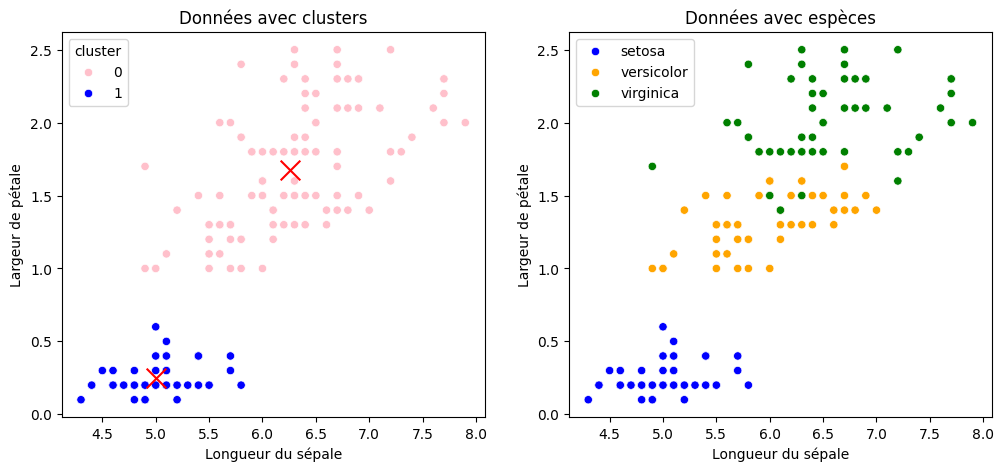

In [78]:
# Je fais la meme chose avec 2 clusters pour voir la différence

# J'instancie mon modèle avec le nombre de clusters choisi
model = KMeans(n_clusters=2)

# J'entraine mon modèle avec le .fit()
model = model.fit(X_scaled)

# J'ajoute ma colonne cluster à mon dataframe et je regarde si elle est bien ajoutée

df["cluster"] = model.labels_
display(df['cluster'].value_counts()) # J'ai bien mes 2 clusters 0 et 1
df.sample(10)

# Je récupère les centres de mes clusters
model.cluster_centers_

# J'inverse la transformation pour avoir les centres de mes clusters dans les unités d'origine
croix = scaler.inverse_transform(model.cluster_centers_)

# Je fais un scatter plot pour visualiser mon dataset de base a gauche et mon dataset avec les clusters a droite
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='sepal_length', y='petal_width', ax=axes[0], hue='cluster', palette=['pink', 'blue'])
axes[0].scatter(croix[:, 0], croix[:, 3], marker='x', c='red', s=200)
axes[0].set_title('Données avec clusters')
axes[0].set_xlabel('Longueur du sépale')
axes[0].set_ylabel('Largeur de pétale')
sns.scatterplot(data=df, x='sepal_length', y='petal_width', ax=axes[1], hue='species', palette=['blue', 'orange', 'green'])
axes[1].set_title('Données avec espèces')
axes[1].set_xlabel('Longueur du sépale')
axes[1].set_ylabel('Largeur de pétale')
plt.legend()
plt.show()

cluster
1    50
3    43
0    30
2    27
Name: count, dtype: int64

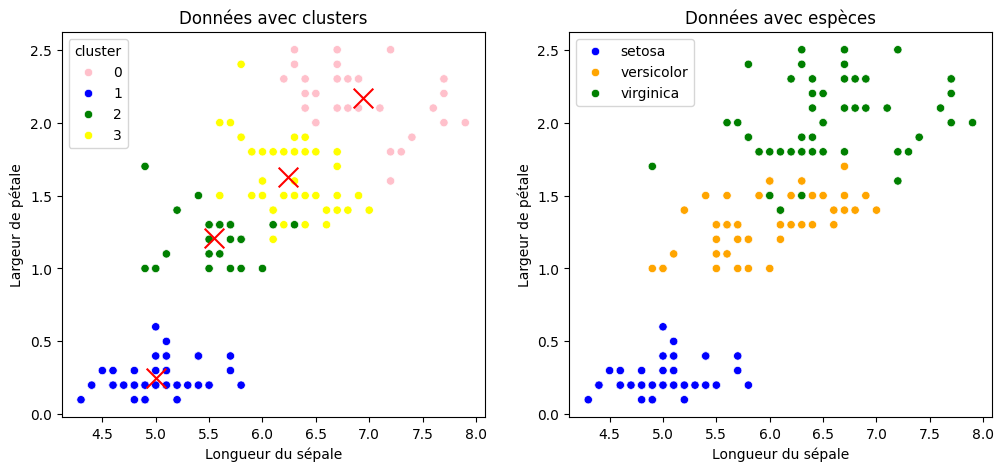

In [79]:
# Je fais la meme chose avec 2 clusters pour voir la différence

# J'instancie mon modèle avec le nombre de clusters choisi
model = KMeans(n_clusters=4)

# J'entraine mon modèle avec le .fit()
model = model.fit(X_scaled)

# J'ajoute ma colonne cluster à mon dataframe et je regarde si elle est bien ajoutée

df["cluster"] = model.labels_
display(df['cluster'].value_counts()) # J'ai bien mes 4 clusters 0, 1, 2 et 3
df.sample(10)

# Je récupère les centres de mes clusters
model.cluster_centers_

# J'inverse la transformation pour avoir les centres de mes clusters dans les unités d'origine
croix = scaler.inverse_transform(model.cluster_centers_)

# Je fais un scatter plot pour visualiser mon dataset de base a gauche et mon dataset avec les clusters a droite
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='sepal_length', y='petal_width', ax=axes[0], hue='cluster', palette=['pink', 'blue', 'green', 'yellow'])
axes[0].scatter(croix[:, 0], croix[:, 3], marker='x', c='red', s=200)
axes[0].set_title('Données avec clusters')
axes[0].set_xlabel('Longueur du sépale')
axes[0].set_ylabel('Largeur de pétale')
sns.scatterplot(data=df, x='sepal_length', y='petal_width', ax=axes[1], hue='species', palette=['blue', 'orange', 'green'])
axes[1].set_title('Données avec espèces')
axes[1].set_xlabel('Longueur du sépale')
axes[1].set_ylabel('Largeur de pétale')
plt.legend()
plt.show()

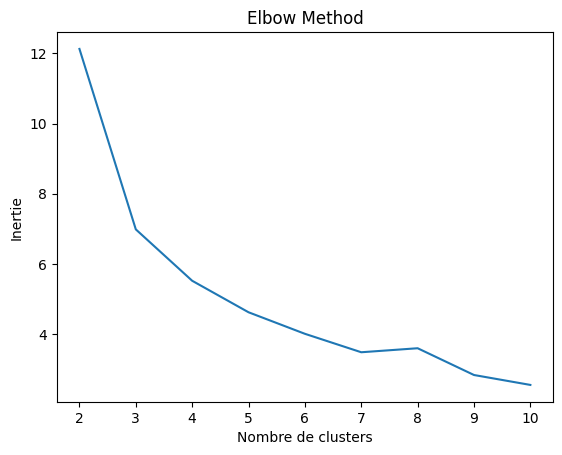

In [83]:
# Je calcule l'inertie pour k allant de 2 à 10 avec la méthode Elbow (coude en francais)
inertia = [ ]
for k in range(2, 11):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Je visualise mes résultats 
plt.plot(range(2, 11), inertia)
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Elbow Method')
plt.show()

On pourrait situer le bon nombre de clusters à 3, l'inertie baisse beaucoup jusqu'a 3, puis ensuite, la courbe commence a s'aplatir légèrement et baisse peu ensuite,
le nombre de clusters a 3 est le bon compromis

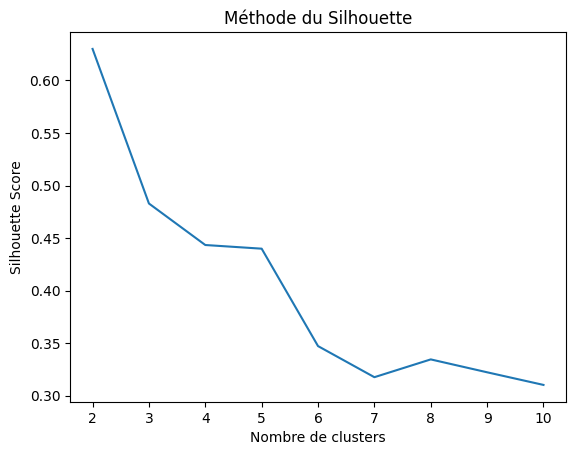

In [84]:
# Je calcule le silhouette score pour k allant de 2 à 10
silhouette_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    silhouette_scores.append(score)

# Je visualise les résultats
plt.plot(range(2, 11), silhouette_scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Silhouette Score')
plt.title('Méthode du Silhouette')
plt.show()

Pour le silouhette score, le nombre optimal semble etre 2 car c'est le nombre le plus proche de 1, en l'occurence 0.63 environ.
Selon l'analyse du graphique silouhette score, j'aurais opté pour 2 clusters mais avec l'elbow method pour 3. 
Sans savoir qu'il y avait 3 espèces, en utilisant les deux methodes, j'aurais surement opté pour 2 clusters mais cela aurait été au final moins pertinent que d'utiliser 3 clusters.
Attention à la séparation purement mathématique d'une part et la pertinence métier d'autre part.